In [66]:
from freyrelab.nets import motifs
import networkx as nx

In [108]:
G = nx.complete_graph(3, create_using=nx.DiGraph())
mc = motifs.count_motifs(G)

In [109]:
mc.complex_feedforwards_count, mc.feedforwards_count, mc.feedbacks3_count

(0, 0, 2)

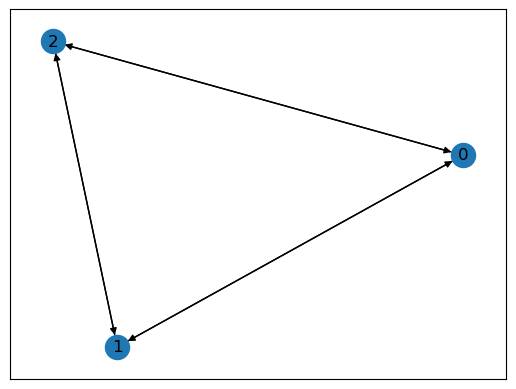

In [110]:
nx.draw_networkx(G)

In [112]:
motifs.giant_component(G), motifs.giant_component_size(G)

(<networkx.classes.digraph.DiGraph at 0x2142af80580>, 3)

(0, 0, 1)

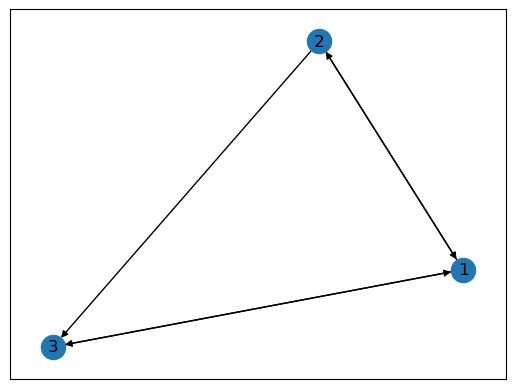

In [40]:
H = nx.DiGraph([(1, 2), (2, 3), (1, 3), (2,1), (3,1)])
nx.draw_networkx(H)
mc = motifs.count_motifs(H)
mc.complex_feedforwards_count, mc.feedforwards_count, mc.feedbacks3_count

In [ ]:
bbb

In [1]:
import numpy as np
import inspect
import networkx as nx
from collections import defaultdict
from netective.structure import properties

from freyrelab.nets import motifs
from freyrelab.nets.paths2 import ShortestPaths, Efficiency, ShortestDistances

In [2]:
parent_class = properties._Property

def get_child_classes(parent_class):
    child_classes = []
    for name, obj in inspect.getmembers(properties):
        if (
            inspect.isclass(obj)
            and issubclass(obj, parent_class)
            and obj != parent_class
        ):
            child_classes.append(obj)
    return child_classes

child_classes = get_child_classes(parent_class)

In [8]:
property_groups = defaultdict(list)

for class_ in child_classes:
    mask = np.packbits((class_._use_direction, class_._use_selfloops, class_._use_giant_component, class_._use_paths)) >> 4
    property_groups[mask.item()].append(class_)

property_groups

defaultdict(list,
            {0: [netective.structure.properties.AverageClusteringCoefficient,
              netective.structure.properties.AverageDegreeNearestNeighbors,
              netective.structure.properties.ClusteringCoefficient,
              netective.structure.properties.RichClub],
             3: [netective.structure.properties.AverageLocalEfficiency,
              netective.structure.properties.AverageShortestPathLength,
              netective.structure.properties.BetweennessCentrality,
              netective.structure.properties.Center,
              netective.structure.properties.Diameter,
              netective.structure.properties.Eccentricity,
              netective.structure.properties.GlobalEfficiency,
              netective.structure.properties.Periphery,
              netective.structure.properties.Radius],
             8: [netective.structure.properties.AverageOutDegreeNearestNeighbors,
              netective.structure.properties.ComplexFeedForwardCircuit

In [9]:
DIRECTED = 8
SELF_LOOPS = 4
GIANT_COMPONENT = 2
PATHS = 1

def get_modify_directed_graphs(property_groups, original_graph):
    graphs = {}
    for mask, class_group in property_groups.items():
        directed = mask & DIRECTED != 0
        
        if not directed:
            continue

        remove_self_loops = mask & SELF_LOOPS == 0
        get_giant_component = mask & GIANT_COMPONENT != 0
        get_paths = mask & PATHS != 0

        graph_copy = original_graph.copy()
        if remove_self_loops:
            graph_copy = properties.remove_self_loops(graph_copy)
        if get_giant_component:
            graph_copy = motifs.giant_component(graph_copy)
        if get_paths:
            net_shortest_paths = ShortestPaths(graph_copy)
            net_shortest_distances = ShortestDistances(graph_copy)
            graphs[mask] = (graph_copy, net_shortest_paths, net_shortest_distances)
        else:    
            graphs[mask] = graph_copy
    
    return graphs


def get_modify_undirected_graphs(property_groups, original_graph):
    graphs = {}
    for mask, class_group in property_groups.items():
        directed = mask & DIRECTED != 0
        
        if directed:
            continue
        
        remove_self_loops = mask & SELF_LOOPS == 0
        get_giant_component = mask & GIANT_COMPONENT != 0
        get_paths = mask & PATHS != 0

        graph_copy = original_graph.copy()
        if remove_self_loops:
            graph_copy = properties.remove_self_loops(graph_copy)
        if get_giant_component:
            graph_copy = list(graph_copy.subgraph(c) for c in nx.connected_components(graph_copy))[0] # TODO: cant get giant_cmoponent for undirected graph (freyrelab)
        if get_paths:
            net_shortest_paths = ShortestPaths(graph_copy)
            net_shortest_distances = ShortestDistances(graph_copy)
            graphs[mask] = (graph_copy, net_shortest_paths, net_shortest_distances)

        else:
            graphs[mask] = graph_copy

    return graphs




def get_instances(property_groups, original_graph):

    instances = {}
    modified_directed_graphs = {}
    modified_undirected_graphs = {}

    if original_graph.is_directed():
        modified_directed_graphs.update(get_modify_directed_graphs(property_groups, original_graph))
        modified_undirected_graphs.update(get_modify_undirected_graphs(property_groups, original_graph.to_undirected()))
    else:
        modified_undirected_graphs.update(get_modify_undirected_graphs(property_groups, original_graph))
    
    inputs = {**modified_directed_graphs, **modified_undirected_graphs}

    for mask, class_group in property_groups.items():
        if mask not in inputs:
            for class_ in class_group:
                print(f"{mask}, {class_.CLASS_NAME} cannot be computed for the input graph.")

        for class_ in class_group:
            property_input = inputs[mask]
            if isinstance(property_input, tuple):
                G = property_input[0]
                net_shortest_paths = property_input[1]
                net_shortest_distances = property_input[2]
                instances[class_.CLASS_NAME] = class_(G, net_shortest_paths=net_shortest_paths, net_shortest_distances=net_shortest_distances)
            else:
                instances[class_.CLASS_NAME] = class_(property_input)
    
    return instances

In [10]:
G = nx.erdos_renyi_graph(100, 0.1, directed=True, seed=42)

instances = get_instances(property_groups, G)

In [11]:
instances

{'Average Clustering Coefficient': <netective.structure.properties.AverageClusteringCoefficient at 0x1aaf4050c10>,
 'Average Degree for Nearest Neighbors (Undirected)': <netective.structure.properties.AverageDegreeNearestNeighbors at 0x1aaf4050490>,
 'Clustering Coefficient': <netective.structure.properties.ClusteringCoefficient at 0x1aaf40506a0>,
 'Rich Club Coefficient': <netective.structure.properties.RichClub at 0x1aaf40500d0>,
 'Average Local Efficiency': <netective.structure.properties.AverageLocalEfficiency at 0x1aaf4050760>,
 'Average Shortest Path Length': <netective.structure.properties.AverageShortestPathLength at 0x1aaf3d4edc0>,
 'Betweenness Centrality': <netective.structure.properties.BetweennessCentrality at 0x1aaf3d4ef10>,
 'Center': <netective.structure.properties.Center at 0x1aaf3d4efa0>,
 'Diameter': <netective.structure.properties.Diameter at 0x1aaf3d4eeb0>,
 'Eccentricity': <netective.structure.properties.Eccentricity at 0x1aaf403c220>,
 'Global Efficiency': <netec

In [12]:
{name: class_.compute() for name, class_ in instances.items()}

{'Average Clustering Coefficient': 0.184808354434922,
 'Average Degree for Nearest Neighbors (Undirected)': array([19.43478261, 19.71428571, 20.65      , 19.06666667, 19.19047619,
        19.63157895, 18.77777778, 18.4       , 18.61111111, 19.6875    ,
        19.20689655, 19.125     , 18.8125    , 19.1875    , 18.10526316,
        19.88888889, 19.30769231, 19.82352941, 17.8125    , 19.33333333,
        19.47619048, 18.75      , 19.47619048, 17.75      , 20.        ,
        18.22222222, 18.5       , 19.45      , 18.72727273, 19.23076923,
        19.1875    , 19.64285714, 18.8       , 19.8       , 19.14285714,
        18.77777778, 19.92307692, 19.16666667, 17.84615385, 19.        ,
        20.11764706, 17.59090909, 18.8125    , 19.27777778, 18.25      ,
        20.52380952, 19.625     , 19.9047619 , 17.92307692, 18.78947368,
        18.9375    , 19.11764706, 19.28571429, 19.63157895, 18.56      ,
        19.61111111, 19.45      , 19.4       , 18.9375    , 18.82352941,
        19.722222

In [ ]:
DIRECTED = 8
SELF_LOOPS = 4
GIANT_COMPONENT = 2
PATHS = 1

def get_modify_graphs(property_groups, original_graph, graphs=None) --> dict:
    """Get the graphs to be modified and the property groups to be used for the modification."""

    graphs = {} if graphs is None else graphs
    
    if original_graph.is_directed():
        undirected_graph = original_graph.to_undirected()
        mask_graph = get_modify_graphs(property_groups, undirected_graph, graphs)


In [61]:
3 & GIANT_COMPONENT

2

In [ ]:
import networkx as nx

def modify_graph(original_graph, mask):
    # Extract individual bits from the mask
    do_modify_A = mask & 0b1000 != 0

    
    